In [1]:
# Carregamento dos dados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("twitter_emojis_ToLD-BR_normalizado.csv")
df.head(20)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm
0,🔄,1,2,3,0.000069,0.000307
1,😴,2,5,7,0.000138,0.000768
2,😆,1,6,7,0.000069,0.000922
3,🐷,1,3,4,0.000069,0.000461
4,⏬,0,1,1,0.000000,0.000154
5,🎉,2,9,11,0.000138,0.001383
6,⛔,0,1,1,0.000000,0.000154
7,💢,0,1,1,0.000000,0.000154
8,👬,0,2,2,0.000000,0.000307
9,📞,0,1,1,0.000000,0.000154


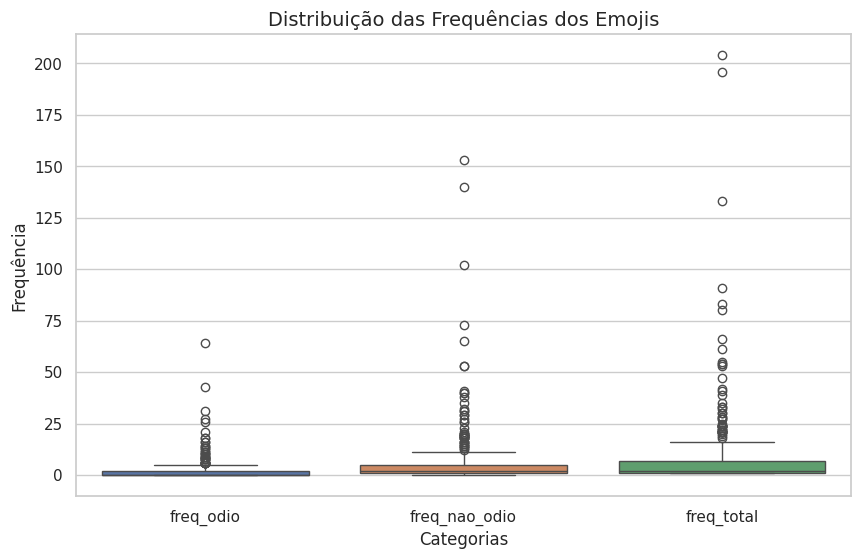

In [2]:
# Selecionar colunas de frequência
dados_boxplot = df[[
    "freq_odio",
    "freq_nao_odio",
    "freq_total"
]]

# Estilo
sns.set(style="whitegrid")

# Criar figura
plt.figure(figsize=(10, 6))

# Boxplot
sns.boxplot(data=dados_boxplot)

# Título e labels
plt.title("Distribuição das Frequências dos Emojis", fontsize=14)
plt.ylabel("Frequência")
plt.xlabel("Categorias")

# Mostrar gráfico
plt.show()

In [3]:
# Quais emojis são mais usados no Instagram, independentemente de ódio?
df.sort_values("freq_total", ascending=False).head(15)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm
47,😂,64,140,204,0.004416,0.021512
308,❤,43,153,196,0.002967,0.023510
313,😍,31,102,133,0.002139,0.015673
177,🏻,18,73,91,0.001242,0.011217
120,😭,18,65,83,0.001242,0.009988
184,🤦,27,53,80,0.001863,0.008144
46,🙏,13,53,66,0.000897,0.008144
327,🤣,26,35,61,0.001794,0.005378
10,👍,14,41,55,0.000966,0.006300
109,🥰,14,40,54,0.000966,0.006146


In [4]:
# Quais emojis são mais usados no Instagram em discurso de ódio?
df.sort_values("freq_odio", ascending=False).head(15)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm
47,😂,64,140,204,0.004416,0.021512
308,❤,43,153,196,0.002967,0.023510
313,😍,31,102,133,0.002139,0.015673
184,🤦,27,53,80,0.001863,0.008144
327,🤣,26,35,61,0.001794,0.005378
236,😡,21,32,53,0.001449,0.004917
177,🏻,18,73,91,0.001242,0.011217
120,😭,18,65,83,0.001242,0.009988
255,♀,16,38,54,0.001104,0.005839
360,🤤,16,19,35,0.001104,0.002919


In [5]:
# Quais emojis são mais usados no Instagram em discurso de não ódio?
df.sort_values("freq_nao_odio", ascending=False).head(15)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm
308,❤,43,153,196,0.002967,0.023510
47,😂,64,140,204,0.004416,0.021512
313,😍,31,102,133,0.002139,0.015673
177,🏻,18,73,91,0.001242,0.011217
120,😭,18,65,83,0.001242,0.009988
46,🙏,13,53,66,0.000897,0.008144
184,🤦,27,53,80,0.001863,0.008144
10,👍,14,41,55,0.000966,0.006300
109,🥰,14,40,54,0.000966,0.006146
231,😔,7,40,47,0.000483,0.006146


In [6]:
# Produção da razão ódio/não ódio no Twitter.

# Evitar divisão por zero
df_analise = df[(df["freq_odio_norm"] > 0) & (df["freq_nao_odio_norm"] > 0)]

df_analise["razao_odio_nao_odio"] = (
    df_analise["freq_odio_norm"] / df_analise["freq_nao_odio_norm"]
)

# Quais emojis possuem maior razão ódio/não ódio no Instagram?
df_analise.sort_values("razao_odio_nao_odio", ascending=False).head(20)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm,razao_odio_nao_odio
258,👌,6,3,9,0.000414,0.000461,0.898151
232,🔞,2,1,3,0.000138,0.000154,0.898151
316,🍁,2,1,3,0.000138,0.000154,0.898151
339,😈,10,6,16,0.000690,0.000922,0.748459
328,🤢,6,4,10,0.000414,0.000615,0.673613
332,😻,4,3,7,0.000276,0.000461,0.598767
103,🤮,11,9,20,0.000759,0.001383,0.548870
104,🤬,11,10,21,0.000759,0.001537,0.493983
26,🍬,1,1,2,0.000069,0.000154,0.449075
38,💟,1,1,2,0.000069,0.000154,0.449075


In [7]:
# Quais emojis são muito mais usados em ódio?
df_analise[df_analise["razao_odio_nao_odio"] > 2].sort_values(
    "razao_odio_nao_odio", ascending=False
).head(10)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm,razao_odio_nao_odio


In [8]:
# Quais emojis são muito mais usados em não ódio?
df_analise[df_analise["razao_odio_nao_odio"] < 0.5].sort_values(
    "razao_odio_nao_odio"
).head(10)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm,razao_odio_nao_odio
213,👏,2,31,33,0.000138,0.004763,0.028973
292,😏,1,15,16,0.000069,0.002305,0.029938
107,👉,1,13,14,0.000069,0.001998,0.034544
265,🎶,2,20,22,0.000138,0.003073,0.044908
148,💙,2,19,21,0.000138,0.002919,0.047271
81,🤙,1,9,10,0.000069,0.001383,0.049897
110,💥,1,9,10,0.000069,0.001383,0.049897
171,💃,1,8,9,0.000069,0.001229,0.056134
270,🎵,1,7,8,0.000069,0.001076,0.064154
256,😜,1,7,8,0.000069,0.001076,0.064154


In [9]:
df_analise.to_csv(
    "etapa1_twitter_emojis.csv",
    index=False,
    encoding="utf-8"
)